# Customer Churn Prediction with Boosting (Steps 1–8)
**Created:** 2025-08-27

This notebook is an end-to-end implementation for the Telco Customer Churn dataset using multiple **boosting algorithms**:
- XGBoost
- LightGBM
- CatBoost
- AdaBoost (baseline)

It follows the roadmap:
1. Data Collection & Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Split Data
6. Modeling (XGBoost, LightGBM, CatBoost, AdaBoost)
7. Hyperparameter Tuning (Optuna)
8. Evaluation (ROC-AUC, F1, Confusion Matrix, ROC/PR curves, SHAP)

> **Dataset:** Telco Customer Churn (CSV file typically named `Telco-Customer-Churn.csv`).
> Place the CSV in the same directory as this notebook before running.

## 0. Environment Setup (one-time)

In [ ]:
# If running locally or in Colab, uncomment the next cell to install deps.
# You can skip installs if your environment already has these packages.

# %pip -q install pandas numpy scikit-learn xgboost lightgbm catboost optuna shap matplotlib

## 1. Imports & Config

In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, average_precision_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier

# Tuning
import optuna

# Plot settings
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['axes.grid'] = True
RANDOM_STATE = 42

## 2. Data Collection & Loading

In [5]:
# Update the path if needed
CSV_PATH = Path("data//raw//WA_Fn-UseC_-Telco-Customer-Churn.csv")

#assert os.path.exists(CSV_PATH), \    f"Could not find {CSV_PATH}. Please place the dataset CSV next to the notebook."

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis (EDA)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4453,1455-UGQVH,Male,0,Yes,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.50,1037.75,Yes
2830,1699-UOTXU,Male,0,No,No,60,Yes,No,DSL,Yes,...,Yes,No,No,No,Two year,No,Electronic check,61.40,3638.25,No
2083,4897-QSUYC,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.15,20.15,Yes
5213,7668-XCFYV,Female,1,Yes,No,17,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,92.55,1614.7,No
4067,9140-CZQZZ,Female,0,Yes,No,68,Yes,No,DSL,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),79.60,5515.8,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64


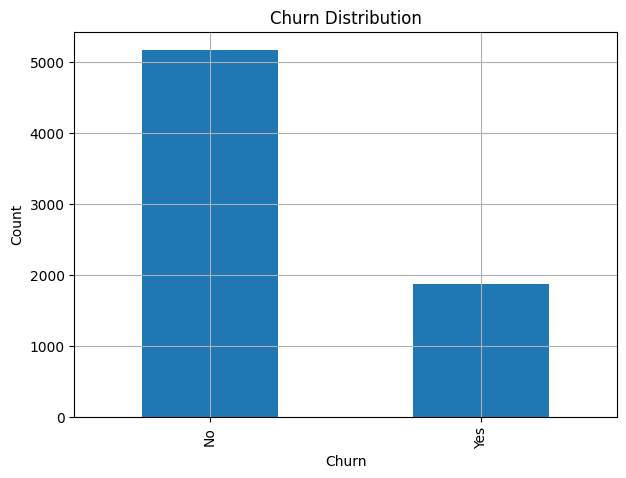

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
display(df.sample(5))
display(df.info())
display(df.describe(include='all').T)

# Target distribution
target_col = 'Churn'
assert target_col in df.columns, "Expected 'Churn' column in the dataset."
print(df[target_col].value_counts(dropna=False))

# Plot target distribution
df[target_col].value_counts().plot(kind='bar', title='Churn Distribution')
plt.xlabel('Churn'); plt.ylabel('Count'); plt.show()

# Numeric columns overview
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

## 4. Data Preprocessing

In [7]:
# Convert target to binary (Yes->1, No->0)
df[target_col] = df[target_col].map({'Yes':1, 'No':0}).astype('int64')

# Common cleaning: TotalCharges should be numeric
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop unique identifier if present
id_cols = [c for c in df.columns if c.lower() in ('customerid', 'id')]
df = df.drop(columns=id_cols) if id_cols else df

# Separate features/target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify columns by dtype (recompute after drops/conversions)
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Numeric features: 4
Categorical features: 15


## 5. Feature Engineering

In [8]:
# Example engineered feature: total_payment = MonthlyCharges * tenure (if both exist)
if set(['MonthlyCharges','tenure']).issubset(X.columns):
    X['total_payment'] = X['MonthlyCharges'] * X['tenure']
    numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Current feature set size:", X.shape[1])

Current feature set size: 20


## 6. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 20) (1409, 20) (5634,) (1409,)


## 7. Preprocessing Pipelines

In [10]:
# For XGB/LGBM/Ada: One-hot encode categoricals + impute missing
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# For CatBoost: we'll pass raw data and give categorical feature indices
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols]

## 8. Modeling: Baseline Models (Default Hyperparameters)

In [11]:
results = {}

# XGBoost
xgb_clf = Pipeline(steps=[
    ('prep', preprocessor_ohe),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    ))
])
xgb_clf.fit(X_train, y_train)
pred_proba = xgb_clf.predict_proba(X_test)[:,1]
pred = (pred_proba >= 0.5).astype(int)
results['XGBoost'] = {
    'roc_auc': roc_auc_score(y_test, pred_proba),
    'f1': classification_report(y_test, pred, output_dict=True)['weighted avg']['f1-score']
}

# LightGBM
lgbm_clf = Pipeline(steps=[
    ('prep', preprocessor_ohe),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        class_weight=None,
        n_jobs=-1
    ))
])
lgbm_clf.fit(X_train, y_train)
pred_proba = lgbm_clf.predict_proba(X_test)[:,1]
pred = (pred_proba >= 0.5).astype(int)
results['LightGBM'] = {
    'roc_auc': roc_auc_score(y_test, pred_proba),
    'f1': classification_report(y_test, pred, output_dict=True)['weighted avg']['f1-score']
}

# CatBoost (native categorical support)
cat_clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    random_seed=RANDOM_STATE,
    verbose=0
)
cat_clf.fit(X_train, y_train, cat_features=cat_features_idx, verbose=0)
pred_proba = cat_clf.predict_proba(X_test)[:,1]
pred = (pred_proba >= 0.5).astype(int)
results['CatBoost'] = {
    'roc_auc': roc_auc_score(y_test, pred_proba),
    'f1': classification_report(y_test, pred, output_dict=True)['weighted avg']['f1-score']
}

# AdaBoost (with simple OHE preprocessing)
ada_clf = Pipeline(steps=[
    ('prep', preprocessor_ohe),
    ('model', AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ))
])
ada_clf.fit(X_train, y_train)
pred_proba = ada_clf.predict_proba(X_test)[:,1]
pred = (pred_proba >= 0.5).astype(int)
results['AdaBoost'] = {
    'roc_auc': roc_auc_score(y_test, pred_proba),
    'f1': classification_report(y_test, pred, output_dict=True)['weighted avg']['f1-score']
}

pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,roc_auc,f1
AdaBoost,0.842035,0.797437
CatBoost,0.841051,0.793692
LightGBM,0.827016,0.780425
XGBoost,0.822367,0.783806


## 9. Cross-Validated ROC-AUC Comparison

In [12]:
def cv_auc(model, X, y, preprocess_type='ohe', cv=5):
    cv_obj = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    if preprocess_type == 'ohe':
        pipe = Pipeline([('prep', preprocessor_ohe), ('model', model)])
        scores = cross_val_score(pipe, X, y, cv=cv_obj, scoring='roc_auc', n_jobs=-1)
    else:
        # For CatBoost: define a function to split and fit with native categoricals
        scores = []
        for tr_idx, va_idx in cv_obj.split(X, y):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
            m = CatBoostClassifier(
                iterations=400, learning_rate=0.05, depth=6,
                random_seed=RANDOM_STATE, verbose=0
            )
            m.fit(X_tr, y_tr, cat_features=cat_features_idx, verbose=0)
            preds = m.predict_proba(X_va)[:,1]
            scores.append(roc_auc_score(y_va, preds))
        scores = np.array(scores)
    return scores

cmp = {}
cmp['XGBoost'] = cv_auc(XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                      subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                      eval_metric='logloss', random_state=RANDOM_STATE),
                        X, y, preprocess_type='ohe')
cmp['LightGBM'] = cv_auc(LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE),
                         X, y, preprocess_type='ohe')
cmp['AdaBoost'] = cv_auc(AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RANDOM_STATE),
                         X, y, preprocess_type='ohe')
cmp['CatBoost'] = cv_auc(None, X, y, preprocess_type='cat')

cv_df = pd.DataFrame({k: v for k, v in cmp.items()})
cv_df.index = [f'Fold {i+1}' for i in range(cv_df.shape[0])]
display(cv_df)
print("\nMean ROC-AUC by model:")
cv_df.mean(axis=0).sort_values(ascending=False)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4139
[LightGBM] [Info] Number of positive: 1495, number of negative: 4140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5635, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265484 -> initscore=-1.017659
[LightGBM] [Info] Start training from score -1.017659
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5635, number of used features: 46
[LightGBM] [Info] [binary:

/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LG

,XGBoost,LightGBM,AdaBoost,CatBoost
Fold 1,0.832170,0.836504,0.861779,0.857121
Fold 2,0.814693,0.818131,0.849287,0.840626
Fold 3,0.838498,0.837216,0.852073,0.855677
Fold 4,0.809264,0.810225,0.835000,0.831575
Fold 5,0.819864,0.822123,0.842578,0.835506



Mean ROC-AUC by model:


AdaBoost    0.848144
CatBoost    0.844101
LightGBM    0.824840
XGBoost     0.822898
dtype: float64

## 10. Hyperparameter Tuning (Optuna)

In [13]:
# To keep runtime reasonable, we'll tune XGBoost with a small number of trials.
# You can increase n_trials for better results.
N_TRIALS = 20

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 3e-1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-2, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    model = Pipeline([('prep', preprocessor_ohe),
                      ('model', XGBClassifier(**params))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_churn')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

print("Best XGB ROC-AUC:", study_xgb.best_value)
print("Best XGB params:", study_xgb.best_trial.params)

[I 2025-08-27 16:51:26,549] A new study created in memory with name: xgb_churn
[I 2025-08-27 16:51:26,977] Trial 0 finished with value: 0.8204135446833176 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.10259273200495607, 'subsample': 0.7900517184437993, 'colsample_bytree': 0.6331921103915027, 'reg_lambda': 0.18872875643085188, 'min_child_weight': 0.12367154732692247}. Best is trial 0 with value: 0.8204135446833176.
[I 2025-08-27 16:51:27,315] Trial 1 finished with value: 0.8038559448678122 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.20265130096113934, 'subsample': 0.847255873766912, 'colsample_bytree': 0.9859648554415971, 'reg_lambda': 0.01130234871021977, 'min_child_weight': 8.007619603966118}. Best is trial 0 with value: 0.8204135446833176.
[I 2025-08-27 16:51:27,823] Trial 2 finished with value: 0.8256231362008961 and parameters: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.034436468207167004, 'subsample': 0.60354585

Best XGB ROC-AUC: 0.8484951425673334
Best XGB params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.026211337685641295, 'subsample': 0.6202859447793164, 'colsample_bytree': 0.7716637230822007, 'reg_lambda': 0.02695781711438303, 'min_child_weight': 1.8718063264}


In [14]:
# (Optional) LightGBM tuning — set RUN_LGBM_TUNE=True to enable
RUN_LGBM_TUNE = True

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 2e-1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': RANDOM_STATE
    }
    model = Pipeline([('prep', preprocessor_ohe),
                      ('model', LGBMClassifier(**params))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return score

if RUN_LGBM_TUNE:
    study_lgbm = optuna.create_study(direction='maximize', study_name='lgbm_churn')
    study_lgbm.optimize(objective_lgbm, n_trials=15, show_progress_bar=False)
    print("Best LGBM ROC-AUC:", study_lgbm.best_value)
    print("Best LGBM params:", study_lgbm.best_trial.params)

[I 2025-08-27 16:51:51,146] A new study created in memory with name: lgbm_churn


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:

/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LG

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1496, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5635, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265484 -> initscore=-1.017659
[LightGBM]

/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-27 16:55:04,319] Trial 7 finished with value: 0.8257692157031045 and parameters: {'n_estimators': 1000, 'learning_rate': 0.01368124779653003, 'num_leaves': 119, 'min_child_samples': 64, 'subsample': 0.8328856786656567, 'colsample_bytree': 0.6112914004867447, 'reg_lambda': 0.12633170230357663}. Best is trial 0 with value: 0.8453183421536732.


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 922
[LightGBM] [Info] Number of data points in the tr

[W 2025-08-27 16:55:42,188] Trial 8 failed with parameters: {'n_estimators': 950, 'learning_rate': 0.15597938790938928, 'num_leaves': 96, 'min_child_samples': 46, 'subsample': 0.8576276419885505, 'colsample_bytree': 0.7267767828669401, 'reg_lambda': 0.001148697799416806} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/68/7wf6zgd96sq0d_79xn0pdbx00000gp/T/ipykernel_90857/1339662095.py", line 18, in objective_lgbm
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()
            ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/benar04/Documents/1. Data_Science/6. GIT_projects/predict_customer_churn/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validati

KeyboardInterrupt: 

In [ ]:
# (Optional) CatBoost tuning — set RUN_CAT_TUNE=True to enable
RUN_CAT_TUNE = True

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 800, step=50),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 2e-1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': RANDOM_STATE,
        'verbose': 0
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features_idx, verbose=0)
        preds = model.predict_proba(X_va)[:,1]
        scores.append(roc_auc_score(y_va, preds))
    return float(np.mean(scores))

if RUN_CAT_TUNE:
    study_cat = optuna.create_study(direction='maximize', study_name='cat_churn')
    study_cat.optimize(objective_cat, n_trials=15, show_progress_bar=False)
    print("Best CatBoost ROC-AUC:", study_cat.best_value)
    print("Best CatBoost params:", study_cat.best_trial.params)

## 11. Fit Best Model (from XGBoost Tuning)

In [15]:
best_xgb_params = study_xgb.best_trial.params
best_xgb = Pipeline([('prep', preprocessor_ohe),
                     ('model', XGBClassifier(**best_xgb_params))])

best_xgb.fit(X_train, y_train)
y_proba = best_xgb.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

print("Holdout ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Classification report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
cm

Holdout ROC-AUC: 0.8484706399028649
Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



array([[939,  96],
       [173, 201]])

## 12. ROC & Precision-Recall Curves

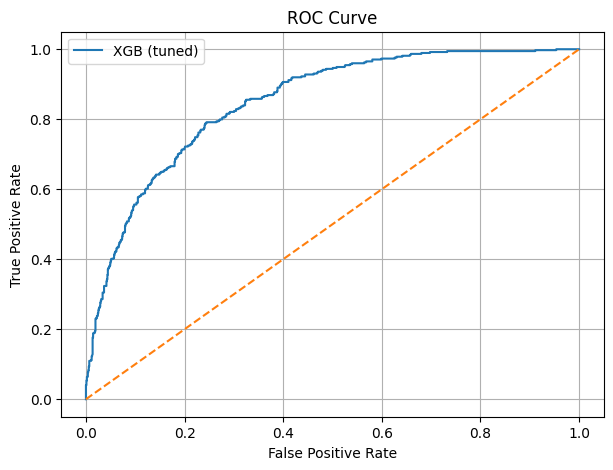

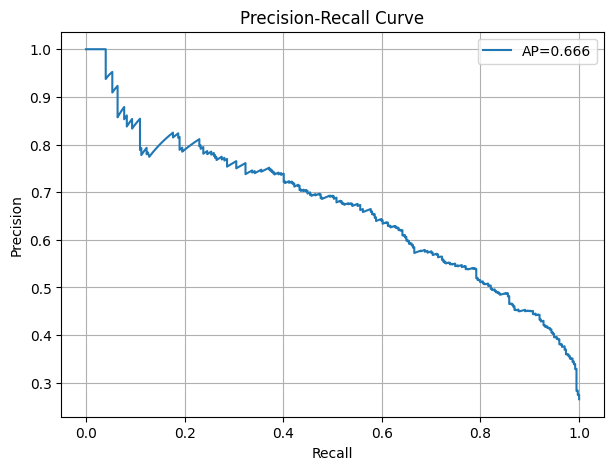

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='XGB (tuned)')
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(); plt.show()

# PR Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.plot(rec, prec, label=f'AP={ap:.3f}')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(); plt.show()

## 13. Explainability with SHAP (TreeExplainer)

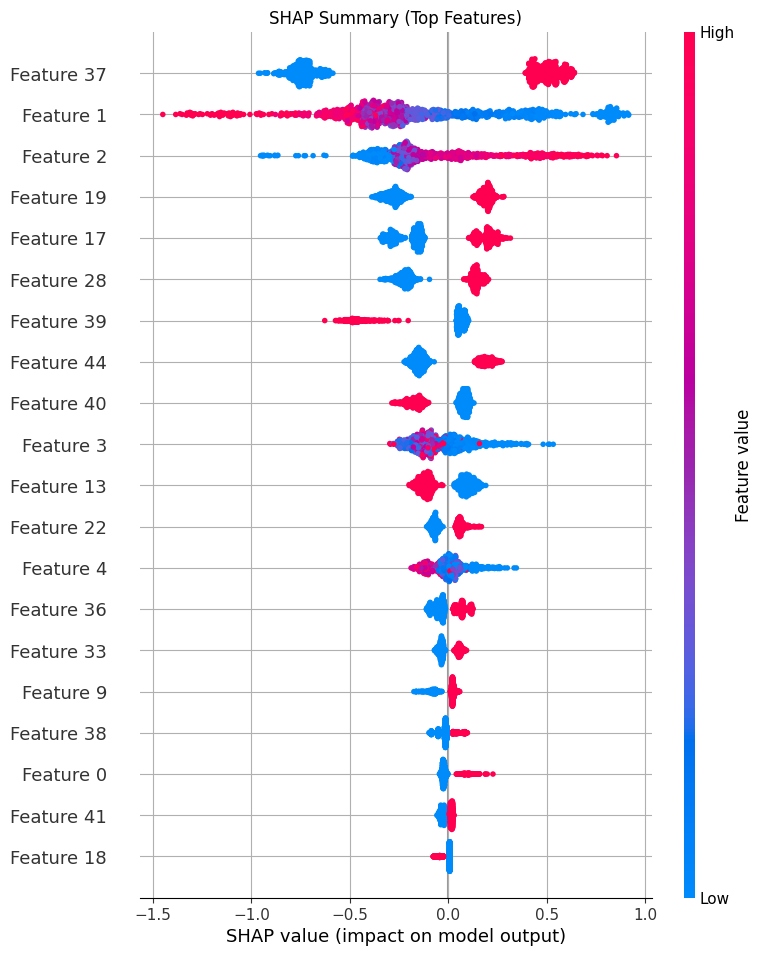

In [17]:
# SHAP can be computationally heavy. We sample for speed if needed.
import shap
# Create a dense test matrix after preprocessing to feed into TreeExplainer
prep = best_xgb.named_steps['prep']
X_test_prepped = prep.transform(X_test)

xgb_model_only = best_xgb.named_steps['model']

explainer = shap.TreeExplainer(xgb_model_only)
# For speed: sample up to 1000 rows
sample_idx = np.random.choice(X_test_prepped.shape[0], size=min(1000, X_test_prepped.shape[0]), replace=False)
shap_values = explainer.shap_values(X_test_prepped[sample_idx])

# SHAP summary plot (bar)
shap.summary_plot(shap_values, X_test_prepped[sample_idx], show=False)
plt.title("SHAP Summary (Top Features)"); plt.show()

## 14. Summary: Baseline Model Comparison

In [18]:
summary_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
summary_df

,roc_auc,f1
AdaBoost,0.842035,0.797437
CatBoost,0.841051,0.793692
LightGBM,0.827016,0.780425
XGBoost,0.822367,0.783806
